# Venmito Data Processing and Analysis
Author: Ignacio Sadurni

Date:    2-23-2025


### Import Neccessary Libraries

In [1208]:
import pandas as pd
import numpy as np
import seaborn as sns
import csv
import yaml
import xml.etree.ElementTree as ET
import altair as alt
from pathlib import Path
from matplotlib import pyplot as plt
from io import StringIO

# Data Processing

## Process Raw Data Files

### Read in people.yml into a data frame

In [1209]:
# Read .yml file and convert to a pandas data frame
with open("people.yml", "r") as file:
    data = yaml.safe_load(file)

people1 = pd.json_normalize(data)
people1.set_index('id', inplace=True)
people1

,Android,Desktop,Iphone,city,email,name,phone
id,,,,,,,
1,1,0,0,"Montreal, Canada",Jamie.Bright@example.com,Jamie Bright,533-849-3913
3,1,1,1,"Toronto, Canada",Yusra.Fletcher@example.com,Yusra Fletcher,385-702-8874
5,1,0,0,"Paris, France",Beatrix.Everett@example.com,Beatrix Everett,194-640-2758
9,1,0,0,"Toronto, Canada",Asa.Vazquez@example.com,Asa Vazquez,504-421-4485
19,1,1,0,"Toronto, Canada",Carmen.Burton@example.com,Carmen Burton,527-368-7429
...,...,...,...,...,...,...,...
993,0,1,1,"Montreal, Canada",Jayson.Sutton@example.com,Jayson Sutton,289-775-9088
994,1,1,0,"London, United Kingdom",Inaaya.Bruce@example.com,Inaaya Bruce,780-773-8755
995,1,0,1,"Montreal, Canada",Raja.Reeves@example.com,Raja Reeves,990-569-7356


In [1210]:
# Clean up data frame columns and format data accordingly
people1[['first_name', 'last_name']] = people1['name'].str.split(' ', expand=True)
people1[['city', 'country']] = people1['city'].str.split(', ', expand=True)
people1 = people1.rename(columns={'name': 'full_name'})
people1 = people1[['full_name', 'first_name', 'last_name', 'email', 'phone', 'city', 'country', 'Android', 'Iphone','Desktop']]
people1

,full_name,first_name,last_name,email,phone,city,country,Android,Iphone,Desktop
id,,,,,,,,,,
1,Jamie Bright,Jamie,Bright,Jamie.Bright@example.com,533-849-3913,Montreal,Canada,1,0,0
3,Yusra Fletcher,Yusra,Fletcher,Yusra.Fletcher@example.com,385-702-8874,Toronto,Canada,1,1,1
5,Beatrix Everett,Beatrix,Everett,Beatrix.Everett@example.com,194-640-2758,Paris,France,1,0,0
9,Asa Vazquez,Asa,Vazquez,Asa.Vazquez@example.com,504-421-4485,Toronto,Canada,1,0,0
19,Carmen Burton,Carmen,Burton,Carmen.Burton@example.com,527-368-7429,Toronto,Canada,1,0,1
...,...,...,...,...,...,...,...,...,...,...
993,Jayson Sutton,Jayson,Sutton,Jayson.Sutton@example.com,289-775-9088,Montreal,Canada,0,1,1
994,Inaaya Bruce,Inaaya,Bruce,Inaaya.Bruce@example.com,780-773-8755,London,United Kingdom,1,0,1
995,Raja Reeves,Raja,Reeves,Raja.Reeves@example.com,990-569-7356,Montreal,Canada,1,1,0


### Read in people.json into a data frame

In [1211]:
# Read in .json file and convert to a pandas data frame
# Format columns accordingly to match the structure and columns of people1
people2 = pd.read_json('people.json')
people2.set_index('id', inplace=True)
people2['full_name'] = people2['first_name'] + " " + people2['last_name']
people2[['city', 'country']] = people2['location'].apply(pd.Series)
people2 = people2.rename(columns={'telephone': 'phone'})
people2 = people2[['full_name', 'first_name', 'last_name', 'email', 'phone', 'devices', 'city', 'country']]

# Split column with list of devices into columns
for index, person in people2.iterrows():
    devices = person['devices']
    for device in devices:
        if device not in people2.columns:
            people2[device] = 0
        people2.at[index, device] = 1

people2 = people2[['full_name', 'first_name', 'last_name', 'email', 'phone', 'city', 'country', 'Android', 'Iphone','Desktop']]
people2


,full_name,first_name,last_name,email,phone,city,country,Android,Iphone,Desktop
id,,,,,,,,,,
1,Jamie Bright,Jamie,Bright,Jamie.Bright@example.com,533-849-3913,Montreal,Canada,1,0,0
2,Arabella Knox,Arabella,Knox,Arabella.Knox@example.com,652-272-9539,Los Angeles,USA,1,1,0
3,Yusra Fletcher,Yusra,Fletcher,Yusra.Fletcher@example.com,385-702-8874,Toronto,Canada,1,1,1
4,Esme Nielsen,Esme,Nielsen,Esme.Nielsen@example.com,621-797-5367,Los Angeles,USA,1,1,0
6,Dean Lewis,Dean,Lewis,Dean.Lewis@example.com,243-955-3782,San Diego,USA,1,1,1
...,...,...,...,...,...,...,...,...,...,...
996,Maria Stephens,Maria,Stephens,Maria.Stephens@example.com,798-578-4631,Toronto,Canada,1,1,0
997,Sam Arias,Sam,Arias,Sam.Arias@example.com,415-467-1137,Chicago,USA,0,1,0
998,Fatimah Johns,Fatimah,Johns,Fatimah.Johns@example.com,520-433-7411,London,United Kingdom,0,1,0


### Create union of the two people data frames

In [1212]:
# Concatenate both people data frames to combine data
# Drop duplicates and sort by the persons id
people = pd.concat([people1, people2]).sort_index().drop_duplicates()
people = people.rename(columns={'Android': 'android', 'Iphone': 'iphone', 'Desktop': 'desktop'})

# Add columns for transfers and transactions to quickly locate these which are associated to the person
people['transfers_in'] = [[] for _ in range(len(people))]
people['transfers_out'] = [[] for _ in range(len(people))]
people['transactions'] = [[] for _ in range(len(people))]
people

,full_name,first_name,last_name,email,phone,city,country,android,iphone,desktop,transfers_in,transfers_out,transactions
id,,,,,,,,,,,,,
1,Jamie Bright,Jamie,Bright,Jamie.Bright@example.com,533-849-3913,Montreal,Canada,1,0,0,[],[],[]
2,Arabella Knox,Arabella,Knox,Arabella.Knox@example.com,652-272-9539,Los Angeles,USA,1,1,0,[],[],[]
3,Yusra Fletcher,Yusra,Fletcher,Yusra.Fletcher@example.com,385-702-8874,Toronto,Canada,1,1,1,[],[],[]
4,Esme Nielsen,Esme,Nielsen,Esme.Nielsen@example.com,621-797-5367,Los Angeles,USA,1,1,0,[],[],[]
5,Beatrix Everett,Beatrix,Everett,Beatrix.Everett@example.com,194-640-2758,Paris,France,1,0,0,[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,Maria Stephens,Maria,Stephens,Maria.Stephens@example.com,798-578-4631,Toronto,Canada,1,1,0,[],[],[]
997,Sam Arias,Sam,Arias,Sam.Arias@example.com,415-467-1137,Chicago,USA,0,1,0,[],[],[]
998,Fatimah Johns,Fatimah,Johns,Fatimah.Johns@example.com,520-433-7411,London,United Kingdom,0,1,0,[],[],[]


### Read in transfers.csv into a data frame

In [1213]:
transfers = pd.read_csv( 'transfers.csv')
transfers = transfers.rename_axis("id")
transfers.to_csv('transfersclean.csv', index=True)
transfers

,sender_id,recipient_id,amount,date
id,,,,
0,926,531,70.47,2022-01-07
1,280,735,21.88,2022-01-10
2,571,737,44.68,2022-01-13
3,958,945,39.94,2022-01-17
4,373,817,6.98,2022-01-17
...,...,...,...,...
522,487,810,22.60,2024-04-27
523,78,356,30.48,2024-04-27
524,682,888,82.91,2024-04-29


### Add transfer ids to related people

In [1214]:
for index, transfer in transfers.iterrows():
    # Locate users from transfers and add to list of transfers
    sender_index = transfer['sender_id']
    people.loc[sender_index, 'transfers_out'].append(transfer.name)
    recipient_index = transfer['recipient_id']
    people.loc[recipient_index, 'transfers_in'].append(transfer.name)
    # Remove duplicate transfers
    people.at[sender_index, 'transfers_out'] = list(set(people.loc[sender_index, 'transfers_out']))
    people.at[recipient_index, 'transfers_in'] = list(set(people.loc[recipient_index, 'transfers_in']))

people

,full_name,first_name,last_name,email,phone,city,country,android,iphone,desktop,transfers_in,transfers_out,transactions
id,,,,,,,,,,,,,
1,Jamie Bright,Jamie,Bright,Jamie.Bright@example.com,533-849-3913,Montreal,Canada,1,0,0,[423],"[264, 329, 446, 342]",[]
2,Arabella Knox,Arabella,Knox,Arabella.Knox@example.com,652-272-9539,Los Angeles,USA,1,1,0,[],[515],[]
3,Yusra Fletcher,Yusra,Fletcher,Yusra.Fletcher@example.com,385-702-8874,Toronto,Canada,1,1,1,[],[],[]
4,Esme Nielsen,Esme,Nielsen,Esme.Nielsen@example.com,621-797-5367,Los Angeles,USA,1,1,0,[],[],[]
5,Beatrix Everett,Beatrix,Everett,Beatrix.Everett@example.com,194-640-2758,Paris,France,1,0,0,[437],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,Maria Stephens,Maria,Stephens,Maria.Stephens@example.com,798-578-4631,Toronto,Canada,1,1,0,[],[288],[]
997,Sam Arias,Sam,Arias,Sam.Arias@example.com,415-467-1137,Chicago,USA,0,1,0,[177],[],[]
998,Fatimah Johns,Fatimah,Johns,Fatimah.Johns@example.com,520-433-7411,London,United Kingdom,0,1,0,[467],[],[]


### Read in promotions.csv into a data frame

In [1215]:
promotions = pd.read_csv( 'promotions.csv')
promotions.rename(columns={'client_email': 'email', 'telephone':'phone'}, inplace=True)
promotions

,id,email,phone,promotion,responded
0,1,NaN,929-575-4315,Coca-Splash,Yes
1,2,NaN,525-796-7991,GatorBoost,Yes
2,3,NaN,441-847-1955,Oreoz,Yes
3,4,Alessandro.French@example.com,216-516-1958,Popsi,Yes
4,5,Isobelle.Davidson@example.com,NaN,Popsi,Yes
...,...,...,...,...,...
195,196,NaN,125-993-7660,Dovee,No
196,197,NaN,139-396-1336,Oreoz,No
197,198,Macie.Payne@example.com,782-737-6408,KittyKat,No
198,199,Martin.Perry@example.com,586-420-6418,GatorBoost,No


In [1216]:
# Try associating user by email otherwise by number and add id to column
for index, row in promotions.iterrows():
    if pd.notna(row['email']):
        person_index = people[people['email'] == row['email']].index
        if not person_index.empty:
            promotions.loc[index, 'person_id'] = person_index[0]
    else:
        person_index = people[people['phone'] == row['phone']].index
        if not person_index.empty:
            promotions.loc[index, 'person_id'] = person_index[0]

promotions['person_id'] = promotions['person_id'].astype(int)
promotions

,id,email,phone,promotion,responded,person_id
0,1,NaN,929-575-4315,Coca-Splash,Yes,144
1,2,NaN,525-796-7991,GatorBoost,Yes,74
2,3,NaN,441-847-1955,Oreoz,Yes,109
3,4,Alessandro.French@example.com,216-516-1958,Popsi,Yes,934
4,5,Isobelle.Davidson@example.com,NaN,Popsi,Yes,530
...,...,...,...,...,...,...
195,196,NaN,125-993-7660,Dovee,No,569
196,197,NaN,139-396-1336,Oreoz,No,27
197,198,Macie.Payne@example.com,782-737-6408,KittyKat,No,170
198,199,Martin.Perry@example.com,586-420-6418,GatorBoost,No,904


In [1217]:
# The following function is used to assign a 1 to indicate that an email or number was provided, 0 otherwise
def transform_value(val):
    if isinstance(val, str) and val == 'nan':
        return 1
    elif isinstance(val, (int, float)) or val.isnumeric():
        return 0
    return 1

promotions['phone'] = promotions['phone'].apply(transform_value)
promotions['email'] = promotions['email'].apply(transform_value)

# Format and save df
promotions.set_index('id', inplace=True)
promotions = promotions[['person_id','promotion','email','phone','responded']]

promotions.to_csv('promotionsclean.csv', index=True)
promotions

,person_id,promotion,email,phone,responded
id,,,,,
1,144,Coca-Splash,0,1,Yes
2,74,GatorBoost,0,1,Yes
3,109,Oreoz,0,1,Yes
4,934,Popsi,1,1,Yes
5,530,Popsi,1,0,Yes
...,...,...,...,...,...
196,569,Dovee,0,1,No
197,27,Oreoz,0,1,No
198,170,KittyKat,1,1,No


### Read in transactions.xml into a data frame

In [1218]:
xml_data = Path('transactions.xml').read_text()
xml = ET.fromstring(xml_data)

In [1219]:
# Read in data into a list of key value pairs for every transaction
transactions = []
for transaction in xml.findall('transaction'):
    items = []
    for item in transaction.find('items').findall('item'):
        items.append({
            'item': item.find('item').text,
            'price': float(item.find('price').text),
            'price_per_item': float(item.find('price_per_item').text),
            'quantity': int(item.find('quantity').text)
        })
    transactions.append({
        'id': int(transaction.get('id')),
        'items': items,
        'phone': transaction.find('phone').text,
        'store': transaction.find('store').text
    })

In [1220]:
# Read this into a data frame
transactions = pd.DataFrame(transactions)
transactions = transactions.drop(columns=['id'])
transactions = transactions.rename_axis('id')
transactions

,items,phone,store
id,,,
0,"[{'item': 'Krafty Cheddar', 'price': 5.0, 'pri...",233-159-4158,Trader Tales
1,"[{'item': 'Colgatex', 'price': 2.0, 'price_per...",725-427-2794,PetPals Mart
2,"[{'item': 'Colgatex', 'price': 3.0, 'price_per...",659-190-9378,Trader Tales
3,"[{'item': 'Krafty Cheddar', 'price': 8.0, 'pri...",334-436-6254,Urban Outfitters Loft
4,"[{'item': 'Popsi', 'price': 3.0, 'price_per_it...",615-102-4849,PetPals Mart
...,...,...,...
145,"[{'item': 'KittyKat', 'price': 2.0, 'price_per...",416-776-3422,Urban Outfitters Loft
146,"[{'item': 'Dovee', 'price': 3.0, 'price_per_it...",627-954-8991,Targeted Treasures
147,"[{'item': 'Flixnet', 'price': 20.0, 'price_per...",934-954-3387,Urban Outfitters Loft


In [1221]:
# Calculate total price amount of each transaction and aggregate to table
def calculate_total(items):
    total_amount = 0
    for item in items:
        total_amount += item['price']
    return total_amount

transactions['amount'] = transactions['items'].apply(calculate_total)
transactions

,items,phone,store,amount
id,,,,
0,"[{'item': 'Krafty Cheddar', 'price': 5.0, 'pri...",233-159-4158,Trader Tales,17.0
1,"[{'item': 'Colgatex', 'price': 2.0, 'price_per...",725-427-2794,PetPals Mart,2.0
2,"[{'item': 'Colgatex', 'price': 3.0, 'price_per...",659-190-9378,Trader Tales,16.0
3,"[{'item': 'Krafty Cheddar', 'price': 8.0, 'pri...",334-436-6254,Urban Outfitters Loft,13.0
4,"[{'item': 'Popsi', 'price': 3.0, 'price_per_it...",615-102-4849,PetPals Mart,13.0
...,...,...,...,...
145,"[{'item': 'KittyKat', 'price': 2.0, 'price_per...",416-776-3422,Urban Outfitters Loft,7.0
146,"[{'item': 'Dovee', 'price': 3.0, 'price_per_it...",627-954-8991,Targeted Treasures,13.0
147,"[{'item': 'Flixnet', 'price': 20.0, 'price_per...",934-954-3387,Urban Outfitters Loft,24.0


In [1222]:
# Locate user from associated phone number and replace the column with the users id
for index, transaction in transactions.iterrows():
    person = people[people['phone'] == transaction['phone']]
    if not person.empty:
        transactions.loc[index, 'person'] = person.index[0]

transactions = transactions[['person','store','amount','items']]
transactions['person'] = transactions['person'].astype(int)

transactions

,person,store,amount,items
id,,,,
0,854,Trader Tales,17.0,"[{'item': 'Krafty Cheddar', 'price': 5.0, 'pri..."
1,341,PetPals Mart,2.0,"[{'item': 'Colgatex', 'price': 2.0, 'price_per..."
2,15,Trader Tales,16.0,"[{'item': 'Colgatex', 'price': 3.0, 'price_per..."
3,371,Urban Outfitters Loft,13.0,"[{'item': 'Krafty Cheddar', 'price': 8.0, 'pri..."
4,480,PetPals Mart,13.0,"[{'item': 'Popsi', 'price': 3.0, 'price_per_it..."
...,...,...,...,...
145,577,Urban Outfitters Loft,7.0,"[{'item': 'KittyKat', 'price': 2.0, 'price_per..."
146,165,Targeted Treasures,13.0,"[{'item': 'Dovee', 'price': 3.0, 'price_per_it..."
147,441,Urban Outfitters Loft,24.0,"[{'item': 'Flixnet', 'price': 20.0, 'price_per..."


In [1223]:
# variable used
all_items = []
for index, row in transactions.iterrows():
    for item_dict in row['items']:
        all_items.append(item_dict['item'])

unique_items = list(set(all_items))
unique_items

['Coca-Splash',
 'Oreoz',
 'Dovee',
 'KittyKat',
 'Popsi',
 'Colgatex',
 'GatorBoost',
 'Krafty Cheddar',
 'RedCow',
 'Flixnet']

### Add transaction ids to related people

In [1224]:
# Create dictionary with id of person and a list of the ids of transactions associated with them
person_transactions = {}
for index, row in transactions.iterrows():
    person = row['person']
    if person not in person_transactions:
        person_transactions[person] = []
    person_transactions[person].append(index)

print(person_transactions)

{854: [0], 341: [1], 15: [2, 138], 371: [3], 480: [4], 850: [5], 564: [6], 297: [7], 305: [8], 169: [9, 57], 752: [10], 89: [11], 202: [12, 36], 526: [13], 370: [14, 60], 132: [15], 109: [16, 95], 54: [17], 986: [18], 894: [19], 742: [20], 328: [21], 368: [22], 735: [23], 944: [24], 693: [25, 125], 533: [26], 602: [27], 97: [28], 667: [29, 63], 990: [30, 82, 122], 224: [31], 927: [32], 701: [33], 136: [34], 528: [35], 799: [37], 35: [38, 91], 862: [39], 171: [40], 146: [41, 105], 540: [42], 374: [43], 692: [44], 86: [45, 124], 179: [46], 23: [47], 686: [48], 308: [49], 126: [50], 516: [51], 697: [52], 556: [53], 212: [54], 345: [55], 970: [56], 624: [58], 217: [59], 518: [61], 27: [62], 28: [64], 158: [65], 124: [66], 615: [67], 706: [68, 141], 223: [69], 207: [70], 935: [71], 182: [72], 486: [73], 17: [74], 184: [75], 174: [76], 211: [77], 85: [78, 86], 10: [79], 671: [80], 259: [81], 43: [83], 258: [84, 130], 519: [85], 48: [87], 702: [88], 362: [89], 64: [90], 175: [92], 116: [93], 

In [1225]:
# Add to people data frame
for key, val in person_transactions.items():
    people.at[key, 'transactions'] = val

people

,full_name,first_name,last_name,email,phone,city,country,android,iphone,desktop,transfers_in,transfers_out,transactions
id,,,,,,,,,,,,,
1,Jamie Bright,Jamie,Bright,Jamie.Bright@example.com,533-849-3913,Montreal,Canada,1,0,0,[423],"[264, 329, 446, 342]",[]
2,Arabella Knox,Arabella,Knox,Arabella.Knox@example.com,652-272-9539,Los Angeles,USA,1,1,0,[],[515],[108]
3,Yusra Fletcher,Yusra,Fletcher,Yusra.Fletcher@example.com,385-702-8874,Toronto,Canada,1,1,1,[],[],[]
4,Esme Nielsen,Esme,Nielsen,Esme.Nielsen@example.com,621-797-5367,Los Angeles,USA,1,1,0,[],[],[]
5,Beatrix Everett,Beatrix,Everett,Beatrix.Everett@example.com,194-640-2758,Paris,France,1,0,0,[437],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,Maria Stephens,Maria,Stephens,Maria.Stephens@example.com,798-578-4631,Toronto,Canada,1,1,0,[],[288],[]
997,Sam Arias,Sam,Arias,Sam.Arias@example.com,415-467-1137,Chicago,USA,0,1,0,[177],[],[]
998,Fatimah Johns,Fatimah,Johns,Fatimah.Johns@example.com,520-433-7411,London,United Kingdom,0,1,0,[467],[],[]


In [1226]:
# Save cleaned data
people.to_csv('peopleclean.csv', index=True)

## Create An Aggregate Data Frame for Item Sales

Here we create a table where each row is an item that was purchased in a transaction. Columns include the transaction_id which is associated to the transaction it belongs to, the person_id associated with the customer, and other data points like quantity, price, store, etc. Having a row for every item will allow us to better access and explore trends related to individual items.

In [1227]:
# From transaction df iterate though items to create the item_sales data frame where each row is an item
def create_item_sales_df(transactions):
    item_sales = []
    for index, row in transactions.iterrows():
        for item_data in row['items']:
            item_sales.append({ # Create item sales data frame with the following schema
                'transaction_id': index,
                'person_id': row['person'],
                'item': item_data['item'],
                'quantity': item_data['quantity'],
                'price_per_unit': item_data['price_per_item'],
                'total_price': item_data['price'],
                'receipt_total': row['amount'],
                'store': row['store'],
                'city': people.loc[row['person'], 'city'],
                'country': people.loc[row['person'], 'country']
            })

    return pd.DataFrame(item_sales)

item_sales = create_item_sales_df(transactions)
item_sales

,transaction_id,person_id,item,quantity,price_per_unit,total_price,receipt_total,store,city,country
0,0,854,Krafty Cheddar,1,5.0,5.0,17.0,Trader Tales,San Diego,USA
1,0,854,Popsi,1,4.0,4.0,17.0,Trader Tales,San Diego,USA
2,0,854,Oreoz,2,4.0,8.0,17.0,Trader Tales,San Diego,USA
3,1,341,Colgatex,1,2.0,2.0,2.0,PetPals Mart,San Diego,USA
4,2,15,Colgatex,1,3.0,3.0,16.0,Trader Tales,New York,USA
...,...,...,...,...,...,...,...,...,...,...
291,147,441,KittyKat,1,2.0,2.0,24.0,Urban Outfitters Loft,San Diego,USA
292,147,441,Colgatex,1,2.0,2.0,24.0,Urban Outfitters Loft,San Diego,USA
293,148,957,Colgatex,1,3.0,3.0,8.0,Trader Tales,San Francisco,USA
294,148,957,Krafty Cheddar,1,5.0,5.0,8.0,Trader Tales,San Francisco,USA


In [1228]:
# Save new df to csv file
item_sales.to_csv('item_sales.csv')

# Cleaned Data

In [1229]:
# The people data frame contains all the information relevant to each user, including a list of teh transfer and transaction ids
# in order to be able to reference these and access them quickly by user
people

,full_name,first_name,last_name,email,phone,city,country,android,iphone,desktop,transfers_in,transfers_out,transactions
id,,,,,,,,,,,,,
1,Jamie Bright,Jamie,Bright,Jamie.Bright@example.com,533-849-3913,Montreal,Canada,1,0,0,[423],"[264, 329, 446, 342]",[]
2,Arabella Knox,Arabella,Knox,Arabella.Knox@example.com,652-272-9539,Los Angeles,USA,1,1,0,[],[515],[108]
3,Yusra Fletcher,Yusra,Fletcher,Yusra.Fletcher@example.com,385-702-8874,Toronto,Canada,1,1,1,[],[],[]
4,Esme Nielsen,Esme,Nielsen,Esme.Nielsen@example.com,621-797-5367,Los Angeles,USA,1,1,0,[],[],[]
5,Beatrix Everett,Beatrix,Everett,Beatrix.Everett@example.com,194-640-2758,Paris,France,1,0,0,[437],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,Maria Stephens,Maria,Stephens,Maria.Stephens@example.com,798-578-4631,Toronto,Canada,1,1,0,[],[288],[]
997,Sam Arias,Sam,Arias,Sam.Arias@example.com,415-467-1137,Chicago,USA,0,1,0,[177],[],[]
998,Fatimah Johns,Fatimah,Johns,Fatimah.Johns@example.com,520-433-7411,London,United Kingdom,0,1,0,[467],[],[]


In [1230]:
# The item_sales data frame contains a row for every single item in every transaction. Columns include the transaction id
# and other details such as the customer, quantity, locations, etc. relevant to that transaction
# This data frame has been built in a way that fields are easily accesible and efficient to generate visualizations
item_sales

,transaction_id,person_id,item,quantity,price_per_unit,total_price,receipt_total,store,city,country
0,0,854,Krafty Cheddar,1,5.0,5.0,17.0,Trader Tales,San Diego,USA
1,0,854,Popsi,1,4.0,4.0,17.0,Trader Tales,San Diego,USA
2,0,854,Oreoz,2,4.0,8.0,17.0,Trader Tales,San Diego,USA
3,1,341,Colgatex,1,2.0,2.0,2.0,PetPals Mart,San Diego,USA
4,2,15,Colgatex,1,3.0,3.0,16.0,Trader Tales,New York,USA
...,...,...,...,...,...,...,...,...,...,...
291,147,441,KittyKat,1,2.0,2.0,24.0,Urban Outfitters Loft,San Diego,USA
292,147,441,Colgatex,1,2.0,2.0,24.0,Urban Outfitters Loft,San Diego,USA
293,148,957,Colgatex,1,3.0,3.0,8.0,Trader Tales,San Francisco,USA
294,148,957,Krafty Cheddar,1,5.0,5.0,8.0,Trader Tales,San Francisco,USA


In [1231]:
# The transactions data frame simply contains the raw data in an organizaed way and has a list of dictionaries
# with the data relevant to the items purchased
transactions

,person,store,amount,items
id,,,,
0,854,Trader Tales,17.0,"[{'item': 'Krafty Cheddar', 'price': 5.0, 'pri..."
1,341,PetPals Mart,2.0,"[{'item': 'Colgatex', 'price': 2.0, 'price_per..."
2,15,Trader Tales,16.0,"[{'item': 'Colgatex', 'price': 3.0, 'price_per..."
3,371,Urban Outfitters Loft,13.0,"[{'item': 'Krafty Cheddar', 'price': 8.0, 'pri..."
4,480,PetPals Mart,13.0,"[{'item': 'Popsi', 'price': 3.0, 'price_per_it..."
...,...,...,...,...
145,577,Urban Outfitters Loft,7.0,"[{'item': 'KittyKat', 'price': 2.0, 'price_per..."
146,165,Targeted Treasures,13.0,"[{'item': 'Dovee', 'price': 3.0, 'price_per_it..."
147,441,Urban Outfitters Loft,24.0,"[{'item': 'Flixnet', 'price': 20.0, 'price_per..."


In [1232]:
# The transfers data frame is the same as the raw csv, but the df index is used as the transfer id referenced in other data frames
transfers

,sender_id,recipient_id,amount,date
id,,,,
0,926,531,70.47,2022-01-07
1,280,735,21.88,2022-01-10
2,571,737,44.68,2022-01-13
3,958,945,39.94,2022-01-17
4,373,817,6.98,2022-01-17
...,...,...,...,...
522,487,810,22.60,2024-04-27
523,78,356,30.48,2024-04-27
524,682,888,82.91,2024-04-29


In [1233]:
# The promotions data frame is similar to the raw source, the email and phone were replaced with 1s and 0s to access
# which medium the user was contacted through, and a column with the person's id was appended.
promotions

,person_id,promotion,email,phone,responded
id,,,,,
1,144,Coca-Splash,0,1,Yes
2,74,GatorBoost,0,1,Yes
3,109,Oreoz,0,1,Yes
4,934,Popsi,1,1,Yes
5,530,Popsi,1,0,Yes
...,...,...,...,...,...
196,569,Dovee,0,1,No
197,27,Oreoz,0,1,No
198,170,KittyKat,1,1,No


# Data Exploration and Visualizations

## Insights from People

Observe the stacked bar chart to get an idea of the amount of users registered in each country and further by city.

Insights:
* Over 700 users in the United States, similarly distributed within its cities
* Smallest user base live in Barcelona

In [1234]:
chart = alt.Chart(people).mark_bar().encode(
    x='country',
    y='count()',
    color='city'
).properties(title='Stacked Bar Chart of Country and City')
chart

alt.Chart(...)

Observe the count of different devices registered by users.

Insight:
* Similar amount of devices registered across different platforms

In [1235]:
print(f"Android users: {people['android'].sum()}")
print(f"iPhone users: {people['iphone'].sum()}")
print(f"Desktop users: {people['desktop'].sum()}")

Android users: 559
iPhone users: 578
Desktop users: 567


## Insights from Transfers

This is an overview of our transfers data. Below we get a summary describing the statistics for the transfer amounts to get an idea of how much money is being sent between users.

Insights:
* Maximum transfer is $172.87

* Minimum transfer is $0.84

* Average transfer is $36.41

In [1236]:
transfers['amount'].describe()

,amount
count,527.000000
mean,36.409620
std,28.936416
min,0.840000
25%,12.755000
50%,30.120000
75%,52.965000
max,172.870000


To better visualize these statistics, observe the histogram and get an idea of how much money is getting transfered and how frequently.

Insights:
* Positively skewed distribution: the larger the transfer amount the less there are

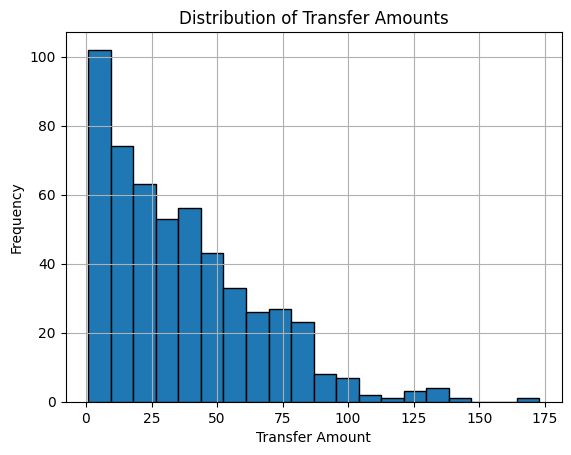

In [1237]:
transfers['amount'].hist(bins=20, edgecolor='black')
plt.xlabel('Transfer Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transfer Amounts')
plt.show()

## Insights from Transactions or Item Sales

In [1238]:
# Find number of unique customers
unique_person_count = item_sales['person_id'].nunique()
print(f"The number of unique people related to item transactions: {unique_person_count}")

The number of unique people related to item transactions: 134


We can look at the amount of items purchased through venmito by store. (Items does not mean transactions, but count all items and their quantities within a transaction)

In [1239]:
store_quantities = {}
for store, store_transactions in transactions.groupby('store'):
    total_quantity = 0
    for _, row in store_transactions.iterrows():
        for item in row['items']:
            total_quantity += item['quantity']
    print(f"Total quantity of items purchased at {store}: {total_quantity}")


Total quantity of items purchased at BestChoice Buy: 57
Total quantity of items purchased at PetPals Mart: 99
Total quantity of items purchased at SparkMart: 44
Total quantity of items purchased at Targeted Treasures: 8
Total quantity of items purchased at Trader Tales: 109
Total quantity of items purchased at Urban Outfitters Loft: 134


Further we calculate and observe the total transaction amount from transactions by store, and compare this with the quantity of items.

In [1240]:
print(f"The total amount for transactions at...")
for store in item_sales['store'].unique():
    total_amount = item_sales[item_sales['store'] == store]['total_price'].sum()
    print(f"\t- {store} is ${total_amount:.0f}")

The total amount for transactions at...
	- Trader Tales is $451
	- PetPals Mart is $323
	- Urban Outfitters Loft is $445
	- BestChoice Buy is $221
	- SparkMart is $231
	- Targeted Treasures is $34


If we want to break down this revenue, lets see how many transactions we have per store and look at the mean, min, and max transfer amounts.

In [1241]:
transactions_by_store = transactions.groupby('store')['amount'].describe()
transactions_by_store

,count,mean,std,min,25%,50%,75%,max
store,,,,,,,,
BestChoice Buy,18.0,12.277778,8.287521,2.0,7.25,10.5,16.25,36.0
PetPals Mart,36.0,8.972222,6.805402,1.0,3.00,8.5,13.00,32.0
SparkMart,13.0,17.769231,7.970297,4.0,12.00,20.0,22.00,32.0
Targeted Treasures,3.0,11.333333,1.527525,10.0,10.50,11.0,12.00,13.0
Trader Tales,36.0,12.527778,7.276130,2.0,7.75,12.0,16.25,34.0
Urban Outfitters Loft,44.0,10.113636,9.048232,1.0,3.00,7.5,13.00,39.0


The following are the aggregate values, so we can compare the transaction amounts from a specific store, with the average between all stores.

In [1242]:
transactions['amount'].describe()

,amount
count,150.000000
mean,11.366667
std,8.110327
min,1.000000
25%,5.250000
50%,10.000000
75%,15.000000
max,39.000000


The following histogram shows the frequency of specific transaction amounts, we can see how they are distributed.

Insights:
*   Positively skewed distribution: the larger the quantity of the transaction, the less frequent

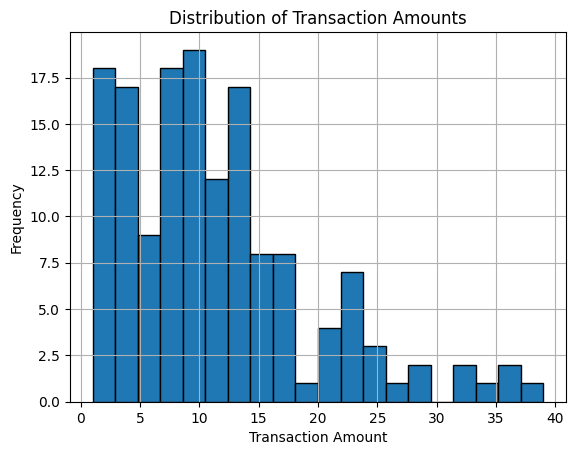

In [1243]:
transactions['amount'].hist(bins=20, edgecolor='black')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

The following heatmap explores correlations between stores and items based on the total number of times the item was transacted, to get an idea of what items are most popular in each store.

Insights:
*   Best Selling Item (by quantity): Dovee in Urban Outfitters Loft
*   White squares mean that the item is not purchased in that city (it might not be supplied or popular)


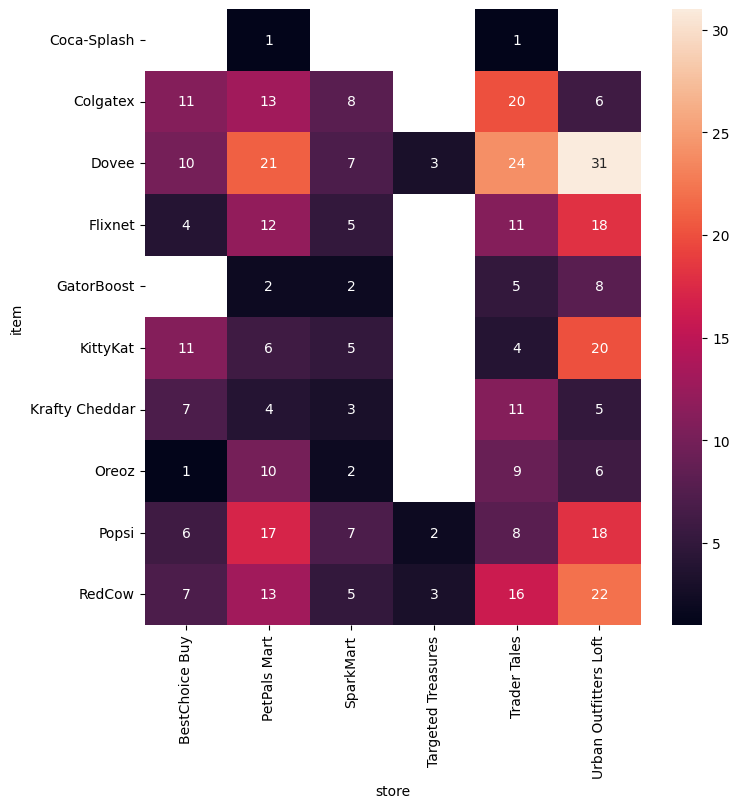

In [1244]:
plt.subplots(figsize=(8, 8))
hist = pd.DataFrame({
    x_label: grp.groupby('item')['quantity'].sum()
    for x_label, grp in item_sales.groupby('store')
})
sns.heatmap(hist, annot=True)
plt.xlabel('store')
plt.ylabel('item')
plt.show()

Similarly, through another heatmap we will explore the correlation between items and cities, to get an idea of which items are more popular where.

Insights:
* Most popular item by number of transactions is Dovee in New York City
* Coca Splash is not popular or not supplied in cities except Los Angeles

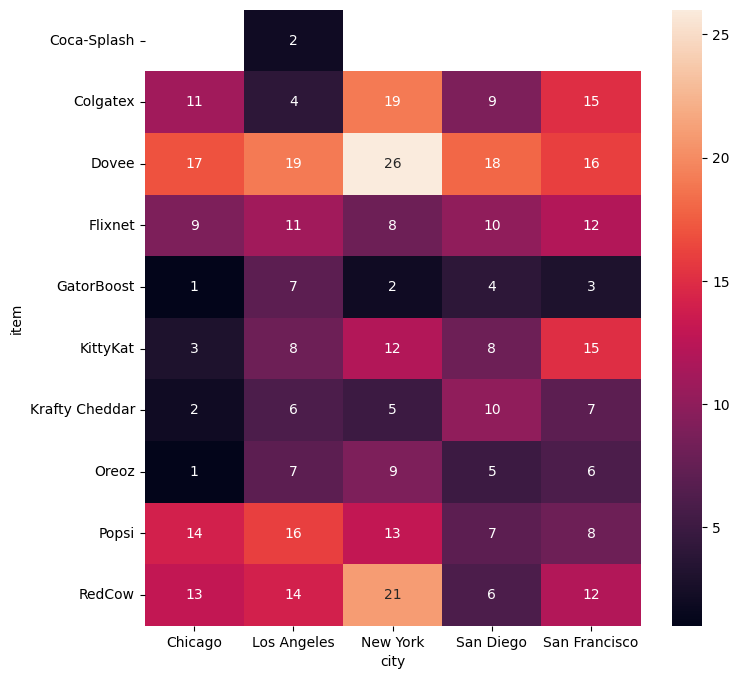

In [1245]:
plt.subplots(figsize=(8, 8))
df = pd.DataFrame({
    x_label: grp.groupby('item')['quantity'].sum()
    for x_label, grp in item_sales.groupby('city')
})
sns.heatmap(df, annot=True)
plt.xlabel('city')
plt.ylabel('item')
plt.show()

The following stacked bar chart gives us an idea of the distribution of amount of transactions by store in different cities.

Insights:
* There are most transactions in New York City and least in Chicago
* Urban Outfitters Loft is more popular in Los Angeles than Chicago
* There arent transactions for Targeted Treasures in California

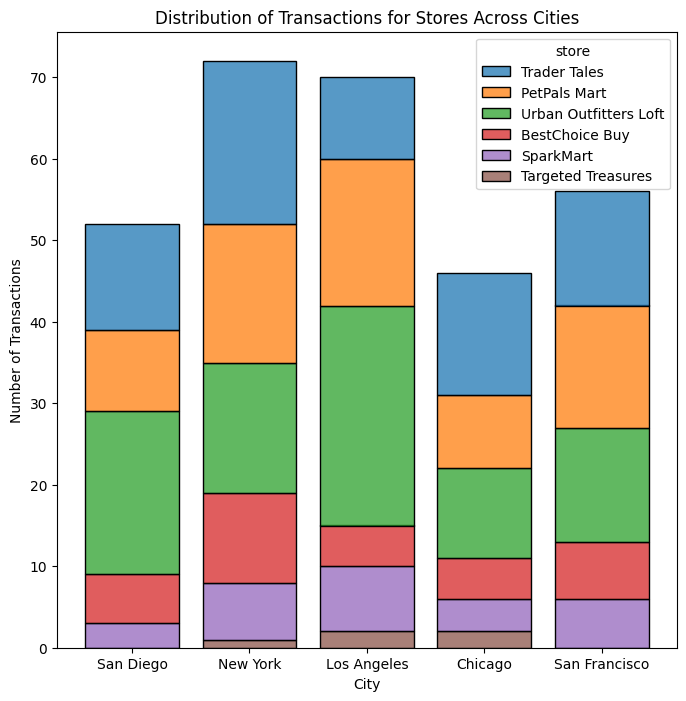

In [1246]:
plt.subplots(figsize=(8, 8))
sns.histplot(data=item_sales, x='city', hue='store', multiple='stack', shrink=0.8)
plt.xlabel('City')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transactions for Stores Across Cities')

try:
    plt.legend(title="Store", bbox_to_anchor=(1.05, 1), loc='left') # raises error but fixes legend
except ValueError:
    pass

plt.show()

## Insights from Promotions

Count the responses for different promotion items and calculate rate.

Insights:

* Popsci promotions have the best response rate with 58.3% being yes
* Colgatex has the lowest ...

In [1247]:
promotions_count = promotions.groupby('promotion')['responded'].value_counts().unstack()
promotions_count = promotions_count.rename(columns={0: 'No', 1: 'Yes'})
promotions_count['Response Rate'] = ((promotions_count['Yes'] / (promotions_count['Yes'] + promotions_count['No']) * 100).round(1).astype(str) + '%')
promotions_count.sort_values('Response Rate', ascending=False)

responded,No,Yes,Response Rate
promotion,,,
Popsi,10,14,58.3%
Oreoz,13,15,53.6%
Dovee,12,13,52.0%
Krafty Cheddar,7,7,50.0%
RedCow,8,8,50.0%
Coca-Splash,10,8,44.4%
GatorBoost,17,11,39.3%
Flixnet,11,4,26.7%
KittyKat,14,5,26.3%
